In [ ]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt 
import os

# Setting up a plotting directory in the repository
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [ ]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

# Number of time periods
T = 1000

In [ ]:
""" 
GARCH(1) Hidden Markov Model
sigma_{t}^2 = alpha_{0,s_{t}} + alpha_{1,s_{t}} * Y_{t-1}^2 + beta_{1,s_{t}} * sigma_{t-1}^2 """

# Number of hidden states k
k = 2

# Setting up initial GARCH(1) parameters g_alpha_0, g_alpha_1, and g_beta_1
g_alpha_0 = np.array([0.05, 0.20])
g_alpha_1 = np.array([0.10, 0.40])
g_beta_1 = np.array([0.80, 0.50])

# Transition matrix P
P = np.array([
    [0.99, 0.01],
    [0.05, 0.95]
])

# States and time series values y together with variances var
states = np.zeros(T, dtype=int)
y = np.zeros(T)
sigma2 = np.zeros(T)

# Setting up initial states and variance squared
states[0] = np.random.choice(k)
s0 = states[0]
sigma2[0] = g_alpha_0[s0] / (1 - g_alpha_1[s0] - g_beta_1[s0])

# Initial time series value is a random variable
# depending on the variance at time step 0
y[0] = np.random.normal(loc=0, scale=np.sqrt(sigma2[0]))

# Looping through the time steps t in T 
for t in range(1, T):
    
    # Finding states at time t and saving to variable s
    states[t] = np.random.choice(k, p=P[states[t-1]])
    s = states[t]

    # Finding the variances at time step t which is 
    # g_alpha_0 for state s plus g_alpha_1 for state s
    # times the time series value of last step squared
    # plus g_beta_1 times the past squared variance  
    sigma2[t] = g_alpha_0[s] + g_alpha_1[s]*(y[t-1]**2) + g_beta_1[s]*sigma2[t-1]

    # The time series value at time s is then the random variable
    # given squared variance at time step t 
    y[t] = np.random.normal(loc=0, scale=np.sqrt(sigma2[t]))

    # Printing out every 100th time step
    if t % 100 == 0:
        print(f"Time = {t:<5} State: {s:<3} Sigma^2: {sigma2[t]:>6.2f}  y: {y[t]:>6.2f}")


Time = 100   State: 0   Sigma^2:   0.50  y:  -0.01
Time = 200   State: 0   Sigma^2:   0.59  y:   1.11
Time = 300   State: 0   Sigma^2:   0.54  y:  -0.01
Time = 400   State: 0   Sigma^2:   0.44  y:   0.22
Time = 500   State: 0   Sigma^2:   6.78  y:   0.12
Time = 600   State: 0   Sigma^2:   0.46  y:   2.10
Time = 700   State: 0   Sigma^2:   0.56  y:   0.33
Time = 800   State: 0   Sigma^2:   0.41  y:   0.30
Time = 900   State: 0   Sigma^2:   0.52  y:  -0.77


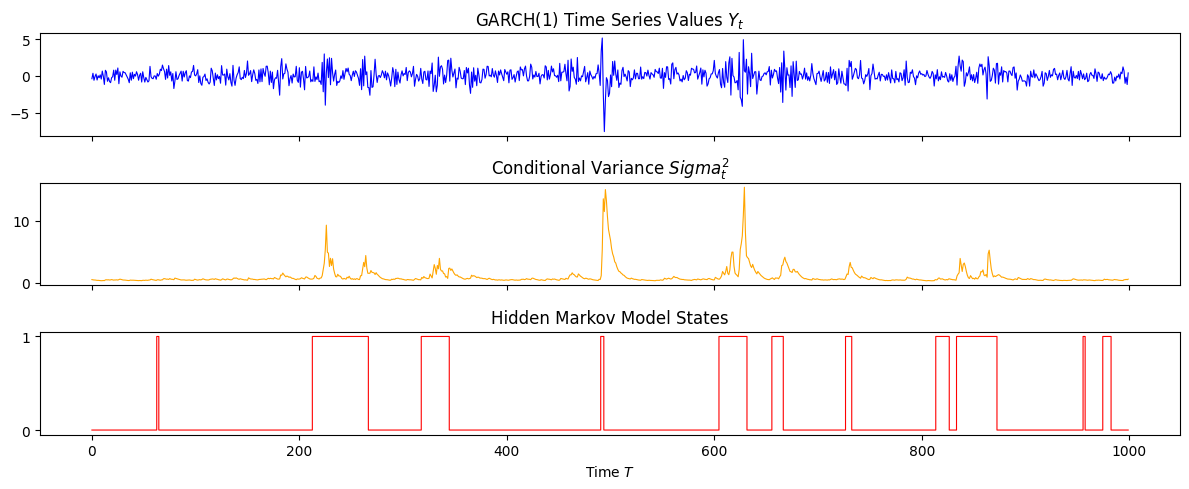

In [8]:
""" Plotting figure """

# Setting up an environment with three panels stacked
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

# First panel
ax1.plot(y, color='blue', linewidth=0.8)
ax1.set_title("GARCH(1) Time Series Values $Y_t$")

# Second panel plotting sigma2 instead of var
ax2.plot(sigma2, color='orange', linewidth=0.8)
ax2.set_title(f"Conditional Variance $Sigma_t^2$")

# Third panel
ax3.plot(states, color='red', drawstyle='steps-mid', linewidth=0.8)
ax3.set_title("Hidden Markov Model States")
ax3.set_yticks([0, 1])

# Arguments for both panels
plt.xlabel("Time $T$")

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, f"garch1-hmm.pdf"), bbox_inches="tight")
plt.show()